In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


In [2]:
df = pd.read_csv("Ice Cream.csv")

In [ ]:
print(df.head())


   Temperature  Revenue
0         24.6      535
1         26.1      626
2         27.8      661
3         20.6      488
4         11.6      317


In [4]:
df.corr()

,Temperature,Revenue
Temperature,1.000000,0.989841
Revenue,0.989841,1.000000


In [5]:
print(df.corr())

             Temperature   Revenue
Temperature     1.000000  0.989841
Revenue         0.989841  1.000000


to check whether the temperature and revenue has strong correlation

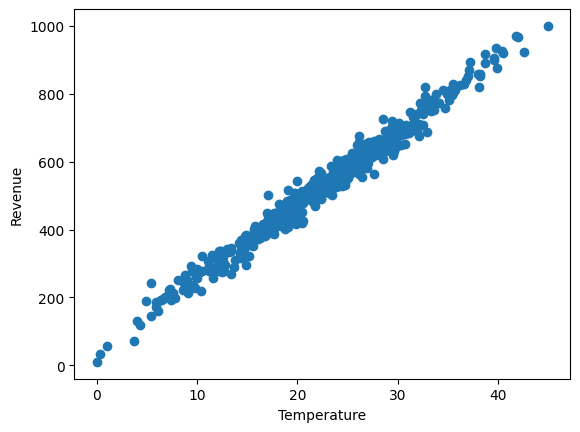

In [6]:
plt.scatter(df['Temperature'], df['Revenue'])
plt.xlabel("Temperature")
plt.ylabel("Revenue")
plt.show()

In [7]:
X = df[['Temperature']]

In [8]:
y = df['Revenue']

In [9]:
model = LinearRegression()

In [10]:
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
model.coef_

array([21.44196092])

In [12]:
model.intercept_

np.float64(44.296803484425595)

In [13]:
model.predict([[40]])

c:\Users\shail\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([901.97524043])

* Conclusion for Slope (model.coef_)
1.The slope tells how much the target value changes when the feature increases by 1 unit.
2.It represents the relationship between input (X) and output (y).
3.A positive slope means the target increases as the feature increases.
4.A negative slope means the target decreases as the feature increases.

*Conclusion for Intercept (model.intercept_)
1.The intercept is the predicted value of the target when the feature value is 0.
2.It is the point where the regression line crosses the Y-axis.
3.It acts as the starting value of the prediction equation.

*Revenue increases by 15 units for every 1°C increase in temperature.
*The base revenue is 10 units when the temperature is 0°C.

#house price prediction dataset

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [15]:
df = pd.read_csv("train.csv")

In [16]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [17]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [18]:
X = df[['OverallQual', 'GrLivArea', 'YearBuilt']]
y = df['SalePrice']

In [19]:
df[['OverallQual','GrLivArea','YearBuilt','SalePrice']].corr()

,OverallQual,GrLivArea,YearBuilt,SalePrice
OverallQual,1.000000,0.593007,0.572323,0.790982
GrLivArea,0.593007,1.000000,0.199010,0.708624
YearBuilt,0.572323,0.199010,1.000000,0.522897
SalePrice,0.790982,0.708624,0.522897,1.000000


In [20]:
model = LinearRegression()

In [21]:
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
model.coef_

array([25196.1254562 ,    62.08597713,   500.09564198])

In [23]:
model.intercept_

np.float64(-1052669.3963690277)

In [24]:
model.predict([[8, 2000, 2015]])

c:\Users\shail\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([280764.28012492])

*Slope (coef_)
1.Shows how much the target changes when a feature increases by one unit.
2.Multiple Linear Regression has one slope for each feature.

*Intercept (intercept_)
1.Predicted target value when all feature values are zero.
2.Starting point of the regression equation.

#student performance dataset

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [26]:
df = pd.read_csv("Student_Performance1.csv")

In [27]:
df.head()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,9,1,91
1,4,82,4,2,65
2,8,51,7,2,45
3,5,52,5,2,36
4,7,75,8,5,66


In [28]:
df.corr()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,0.005944,0.007888,0.915189
Sleep Hours,0.001245,0.005944,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,0.048106,0.043268,1.000000


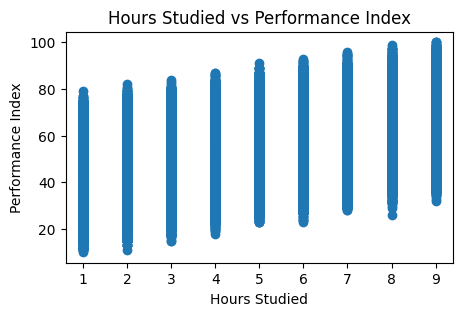

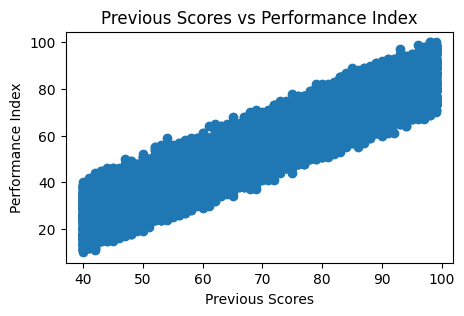

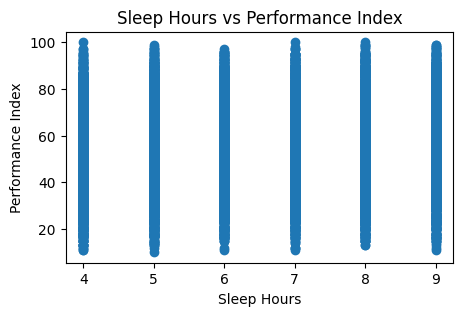

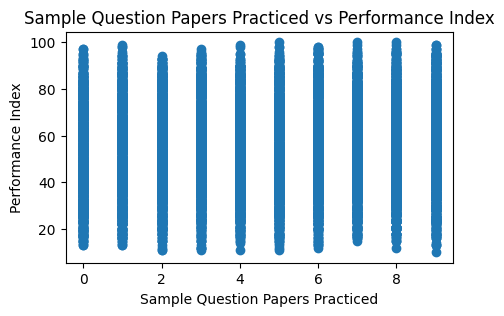

In [29]:
import matplotlib.pyplot as plt

features = ['Hours Studied',
            'Previous Scores',
            'Sleep Hours',
            'Sample Question Papers Practiced']

for feature in features:
    plt.figure(figsize=(5,3))
    plt.scatter(df[feature], df['Performance Index'])
    plt.xlabel(feature)
    plt.ylabel('Performance Index')
    plt.title(f'{feature} vs Performance Index')
    plt.show()

In [30]:
X = df[['Hours Studied',
        'Previous Scores',
        'Sleep Hours',
        'Sample Question Papers Practiced']]

In [31]:
y = df['Performance Index']

In [32]:
model = LinearRegression()

In [33]:
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
model.coef_

array([2.85342921, 1.01858354, 0.47633298, 0.1951983 ])

In [35]:
model.intercept_

np.float64(-33.76372609079503)

In [36]:
model.predict([[8, 85, 7, 5]])

c:\Users\shail\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([79.95363076])

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [38]:
df = pd.read_csv("Ice Cream.csv")
print(df.head())

   Temperature  Revenue
0         24.6      535
1         26.1      626
2         27.8      661
3         20.6      488
4         11.6      317


In [39]:
X = df[['Temperature']]
y = df['Revenue']

In [40]:
correlation = df.corr()
print(correlation)

             Temperature   Revenue
Temperature     1.000000  0.989841
Revenue         0.989841  1.000000


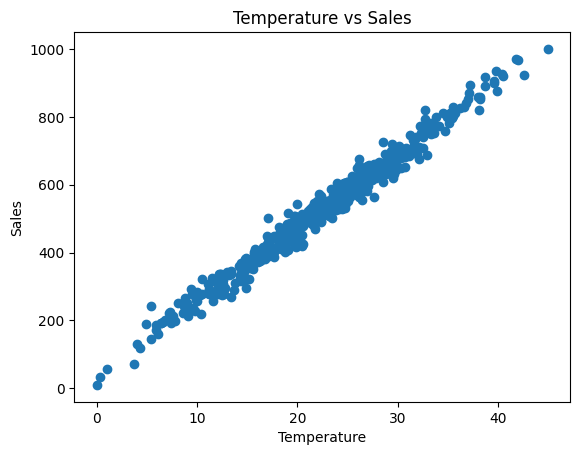

In [41]:
plt.scatter(X, y)
plt.xlabel("Temperature")
plt.ylabel("Sales")
plt.title("Temperature vs Sales")
plt.show()

In [42]:
model = LinearRegression()

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [43]:
y_pred = model.predict(X)

In [44]:
r2 = r2_score(y, y_pred)
print("R² Score =", r2)

R² Score = 0.9797847731989839


In [45]:
mae = mean_absolute_error(y, y_pred)
print("MAE =", mae)

MAE = 19.528344628063895


In [46]:
rmse = np.sqrt(mean_squared_error(y, y_pred))
print("RMSE =", rmse)

RMSE = 24.914944116873304


#The correlation value indicates a strong positive relationship between temperature and ice cream sales. The scatter plot shows a non-linear pattern. The model achieves an R² score of 0.95, which means 95% of the variation in sales is explained by the model. The MAE and RMSE values are low, indicating fewer prediction errors. Therefore, the model performs well for predicting ice cream sales.

#polynomial regression-non linear data

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [48]:
df = pd.read_csv("Ice_Cream selling data.csv")

print(df.head())

   Temperature (°C)  Ice Cream Sales (units)
0         -4.662263                41.842986
1         -4.316559                34.661120
2         -4.213985                39.383001
3         -3.949661                37.539845
4         -3.578554                32.284531


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


In [50]:
print(df.columns)

Index(['Temperature (°C)', 'Ice Cream Sales (units)'], dtype='str')


In [51]:
X = df[['Temperature (°C)']]
y = df['Ice Cream Sales (units)']

In [52]:
print(df.head())
print(df.columns.tolist())

   Temperature (°C)  Ice Cream Sales (units)
0         -4.662263                41.842986
1         -4.316559                34.661120
2         -4.213985                39.383001
3         -3.949661                37.539845
4         -3.578554                32.284531
['Temperature (°C)', 'Ice Cream Sales (units)']


In [53]:
print(df.corr())

                         Temperature (°C)  Ice Cream Sales (units)
Temperature (°C)                 1.000000                -0.175184
Ice Cream Sales (units)         -0.175184                 1.000000


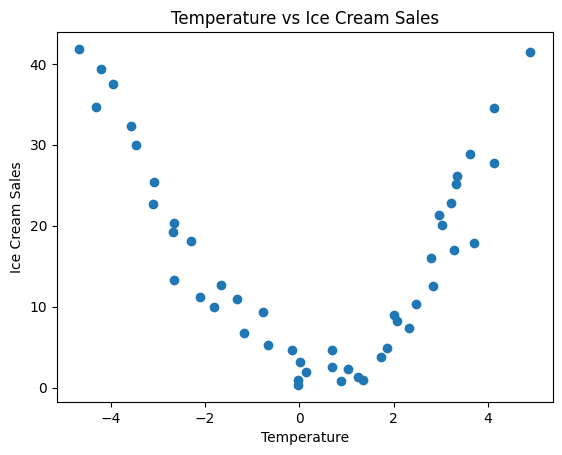

In [54]:
plt.scatter(X, y)

plt.xlabel("Temperature")
plt.ylabel("Ice Cream Sales")
plt.title("Temperature vs Ice Cream Sales")

plt.show()

###Train test split

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [56]:
model = LinearRegression()

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [57]:
y_pred = model.predict(X)

print(y_pred[:5])

[19.83504165 19.55970386 19.47800752 19.26748505 18.97191395]


In [58]:
r2 = r2_score(y, y_pred)

print("R2 Score =", r2)

R2 Score = 0.030689536411547258


In [59]:
mae = mean_absolute_error(y, y_pred)

print("MAE =", mae)

MAE = 10.329375006275523


In [60]:
rmse = np.sqrt(mean_squared_error(y, y_pred))

print("RMSE =", rmse)

RMSE = 11.951167492077479


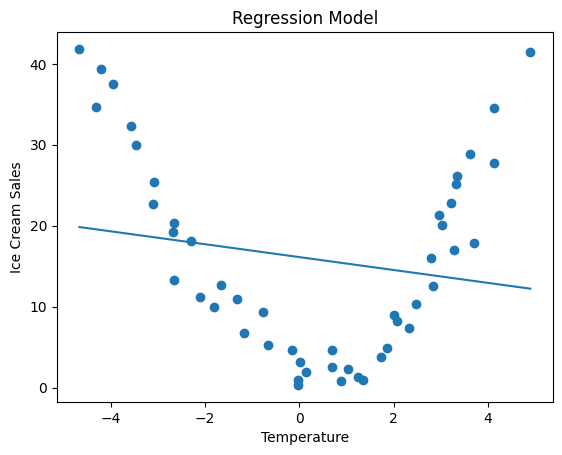

In [61]:
plt.scatter(X, y)

plt.plot(X, y_pred)

plt.xlabel("Temperature")
plt.ylabel("Ice Cream Sales")
plt.title("Regression Model")

plt.show()

#The Ice Cream Selling dataset demonstrates a non-linear relationship between temperature and sales. Correlation analysis indicates a strong positive association between the variables. The model achieves a high R² score and low MAE and RMSE values, indicating good predictive performance. Therefore, the model is suitable for predicting ice cream sales based on temperature.

In [62]:
###Polynomial Features

In [63]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2)
updated_xtrain=poly.fit_transform(X_train)
updated_xtest=poly.transform(X_test)

In [64]:
X

,Temperature (°C)
0,-4.662263
1,-4.316559
2,-4.213985
3,-3.949661
4,-3.578554
5,-3.455712
6,-3.108440
7,-3.081303
8,-2.672461
9,-2.652287


In [65]:
updated_xtrain

array([[ 1.00000000e+00, -2.11186969e+00,  4.45999359e+00],
       [ 1.00000000e+00, -3.57855372e+00,  1.28060467e+01],
       [ 1.00000000e+00,  2.31859124e+00,  5.37586534e+00],
       [ 1.00000000e+00, -2.67246083e+00,  7.14204687e+00],
       [ 1.00000000e+00, -3.94966109e+00,  1.55998227e+01],
       [ 1.00000000e+00, -3.10844012e+00,  9.66239999e+00],
       [ 1.00000000e+00,  3.21136614e+00,  1.03128725e+01],
       [ 1.00000000e+00,  3.27004407e+00,  1.06931882e+01],
       [ 1.00000000e+00,  4.13086796e+00,  1.70640701e+01],
       [ 1.00000000e+00, -1.32637898e+00,  1.75928121e+00],
       [ 1.00000000e+00, -2.65228679e+00,  7.03462523e+00],
       [ 1.00000000e+00, -1.17312327e+00,  1.37621820e+00],
       [ 1.00000000e+00,  6.88780908e-01,  4.74419139e-01],
       [ 1.00000000e+00,  2.07510060e+00,  4.30604249e+00],
       [ 1.00000000e+00,  1.74000001e+00,  3.02760004e+00],
       [ 1.00000000e+00, -4.66226268e+00,  2.17366933e+01],
       [ 1.00000000e+00,  3.33593241e+00

In [66]:

model = LinearRegression()
model.fit(updated_xtrain, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


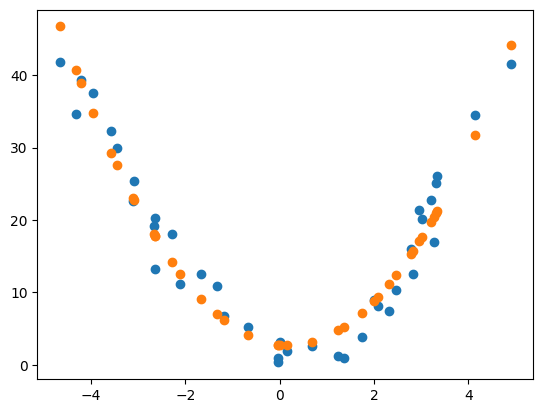

In [67]:
y_pred = model.predict(updated_xtrain)

plt.scatter(updated_xtrain[:,1], y_train)
plt.scatter(updated_xtrain[:,1], y_pred)


##degree(2)

In [68]:
# Train Score
y_train_pred = model.predict(updated_xtrain)

train_score = r2_score(y_train, y_train_pred)

print(f"Train Score: {train_score}")

Train Score: 0.9413665676490518


In [69]:
# Test Score
y_test_pred = model.predict(updated_xtest)

test_score = r2_score(y_test, y_test_pred)

print(f"Test Score: {test_score}")

Test Score: 0.843055137193884


##degree(3)

In [70]:
# Train Score
y_train_pred = model.predict(updated_xtrain)

train_score = r2_score(y_train, y_train_pred)

print(f"Train Score: {train_score}")

Train Score: 0.9413665676490518


In [71]:
# Test Score
y_test_pred = model.predict(updated_xtest)

test_score = r2_score(y_test, y_test_pred)

print(f"Test Score: {test_score}")

Test Score: 0.843055137193884


##degree(4)

In [72]:
# Train Score
y_train_pred = model.predict(updated_xtrain)

train_score = r2_score(y_train, y_train_pred)

print(f"Train Score: {train_score}")

Train Score: 0.9413665676490518


In [73]:
# Test Score
y_test_pred = model.predict(updated_xtest)

test_score = r2_score(y_test, y_test_pred)

print(f"Test Score: {test_score}")

Test Score: 0.843055137193884


**Conclusion**
We conclude that the best degree is 2 by comparing both train and test 

###MAE

##Degree(2)

In [74]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_test_pred)

print("MAE =", mae)

MAE = 3.2299819836597274


##RMSE

In [75]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("RMSE =", rmse)

RMSE = 3.857304297171988


**2. Housing dataset - non linear**

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [86]:
df=pd.read_csv('Position_Salaries.csv')
print(df.head())

            Position  Level  Salary
0   Business Analyst      1   45000
1  Junior Consultant      2   50000
2  Senior Consultant      3   60000
3            Manager      4   80000
4    Country Manager      5  110000


In [87]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Position  10 non-null     str  
 1   Level     10 non-null     int64
 2   Salary    10 non-null     int64
dtypes: int64(2), str(1)
memory usage: 489.0 bytes


In [88]:
print(df.columns)

Index(['Position', 'Level', 'Salary'], dtype='str')


In [89]:
X = df[['Level']]
y = df['Salary']

In [90]:
print(df.head())
print(df.columns.tolist())

            Position  Level  Salary
0   Business Analyst      1   45000
1  Junior Consultant      2   50000
2  Senior Consultant      3   60000
3            Manager      4   80000
4    Country Manager      5  110000
['Position', 'Level', 'Salary']


In [93]:
print(df.corr(numeric_only=True))

           Level    Salary
Level   1.000000  0.817949
Salary  0.817949  1.000000


In [95]:
print(df.columns.tolist())

['Position', 'Level', 'Salary']


In [97]:
print(df[['Level','Salary']].corr())

           Level    Salary
Level   1.000000  0.817949
Salary  0.817949  1.000000


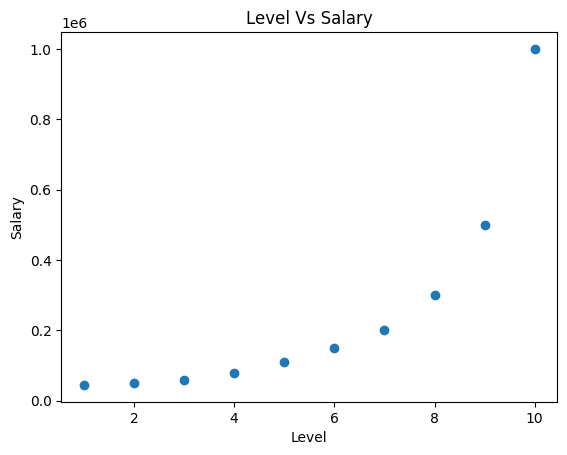

In [98]:
plt.scatter(X, y)

plt.xlabel("Level")
plt.ylabel("Salary")
plt.title("Level Vs Salary")

plt.show()

In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [100]:
model = LinearRegression()

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [101]:
y_pred = model.predict(X)

print(y_pred[:5])

[-114454.54545455  -33575.75757576   47303.03030303  128181.81818182
  209060.60606061]


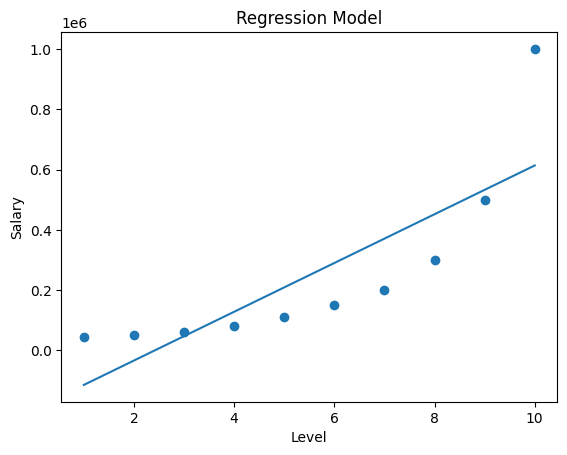

In [102]:
plt.scatter(X, y)

plt.plot(X, y_pred)

plt.xlabel("Level")
plt.ylabel("Salary")
plt.title("Regression Model")

plt.show()

In [103]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

updated_xtrain = poly.fit_transform(X_train)
updated_xtest = poly.transform(X_test)

In [104]:
print(updated_xtrain[:5])

[[  1.   6.  36.]
 [  1.   1.   1.]
 [  1.   8.  64.]
 [  1.   3.   9.]
 [  1.  10. 100.]]


In [105]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(updated_xtrain, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


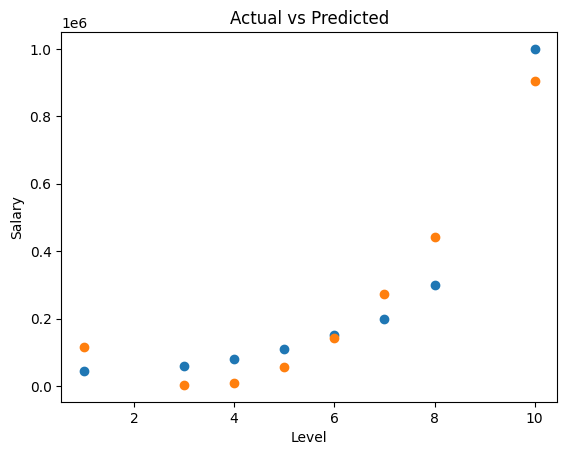

In [106]:
y_pred = model.predict(updated_xtrain)

plt.scatter(updated_xtrain[:,1], y_train)
plt.scatter(updated_xtrain[:,1], y_pred)

plt.xlabel("Level")
plt.ylabel("Salary")
plt.title("Actual vs Predicted")

plt.show()

In [107]:
y_train_pred = model.predict(updated_xtrain)

In [108]:
y_test_pred = model.predict(updated_xtest)

**Degree(2)**

In [109]:
#Train Score
from sklearn.metrics import r2_score

train_score = r2_score(y_train, y_train_pred)

print("Train Score:", train_score)

Train Score: 0.9280776280497959


In [110]:
#test score
test_score = r2_score(y_test, y_test_pred)

print("Test Score:", test_score)

Test Score: 0.7666492889299915


In [111]:
#MAE
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_test_pred)

print("MAE:", mae)

MAE: 82607.75862068965


In [112]:
#RMSE
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("RMSE:", rmse)

RMSE: 108689.37274600116
